In [ ]:
# This script fetches Bitcoin data, generates trading signals based on Dow Theory,
# and plots the signals on a chart.

from strategy.dow_theory.gen_strategy import generate_signals
from test_dow_theory import fetch_btc_data, plot_btc_signals

btc_data = fetch_btc_data()
signals = generate_signals(btc_data)
plot_btc_signals(btc_data, signals)
print(signals.tail(10))

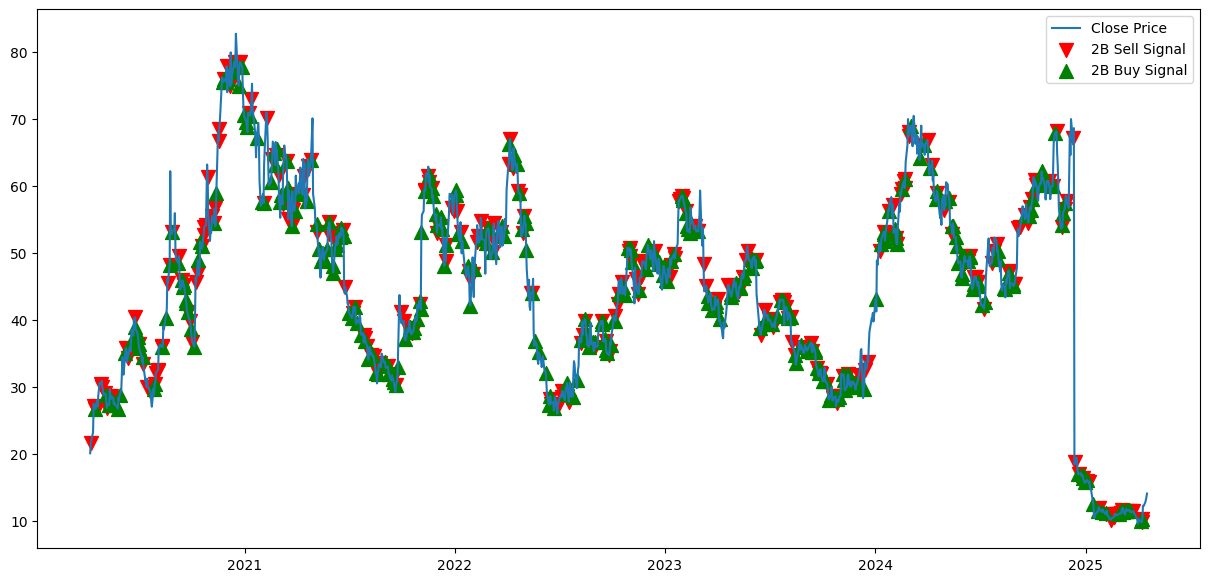

            trend_line_up  trend_line_down  buy_condition1  buy_condition2  \
date                                                                         
2025-04-04           9.41            11.94           False            True   
2025-04-07           9.37            11.94           False           False   
2025-04-08           9.37            11.94           False            True   
2025-04-09           9.12            11.94           False           False   
2025-04-10           9.12            12.50           False            True   
2025-04-11           9.12            12.50           False            True   
2025-04-14           9.12            12.90           False            True   
2025-04-15           9.12            13.19           False            True   
2025-04-16           9.12            13.58           False            True   
2025-04-17           9.12            14.20           False            True   

            buy_condition3  123_buy_signal  sell_condition1  se

In [1]:
# The following code fetches stock data for Apple Inc. (AAPL)
# and generates trading signals based on Dow Theory.

from src.io.read_data import load_stocks_data
from strategy.dow_theory.gen_strategy import generate_signals
from test_dow_theory import plot_stock_signals

df = load_stocks_data('kros', '2025-04-21')
signals = generate_signals(df)
plot_stock_signals(df, signals)
print(signals.tail(10))

In [2]:
# print(signals.columns)
print(signals[["123_buy_signal", "123_sell_signal", "2B_buy_signal", "2B_sell_signal"]].tail(10))


            123_buy_signal  123_sell_signal  2B_buy_signal  2B_sell_signal
date                                                                      
2025-04-04           False            False          False           False
2025-04-07           False            False           True           False
2025-04-08           False            False          False            True
2025-04-09           False            False           True            True
2025-04-10           False            False          False           False
2025-04-11           False            False          False           False
2025-04-14           False            False          False           False
2025-04-15           False            False          False           False
2025-04-16           False            False          False           False
2025-04-17           False            False          False           False


/data/quant_stocks/src/strategy/dow_theory/gen_strategy.py:122: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["upward_trend"] = upward_trends
/data/quant_stocks/src/strategy/dow_theory/gen_strategy.py:123: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["downward_trend"] = downward_trends


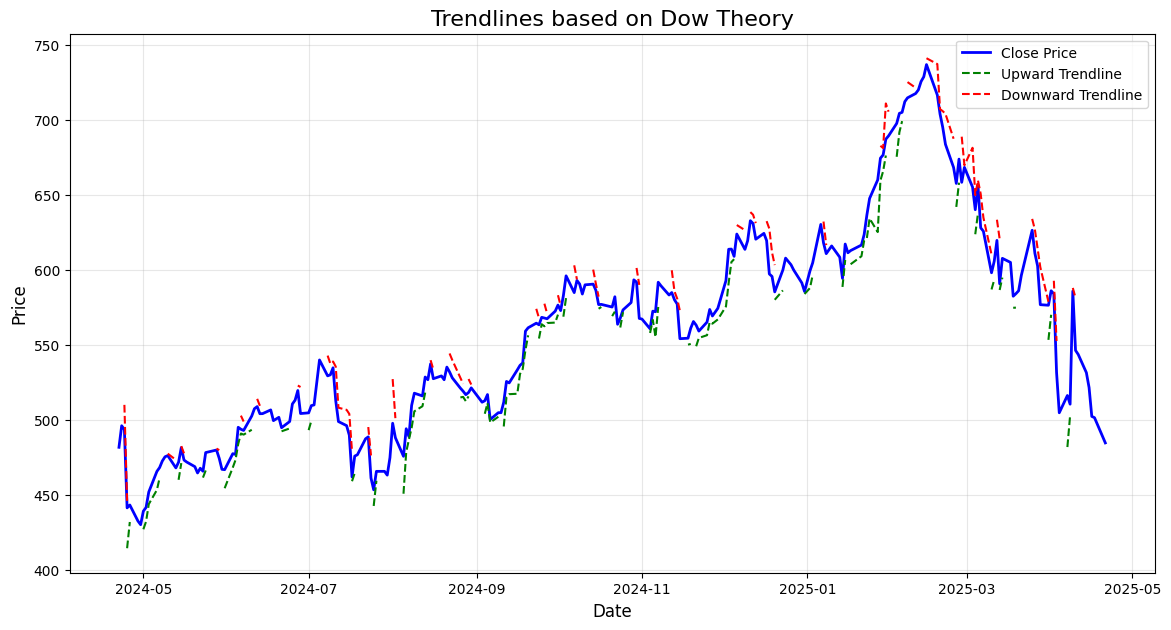

In [13]:
import pandas as pd
from src.io.read_data import load_stocks_data

from strategy.dow_theory.gen_strategy import calculate_trendlines
from test_dow_theory import plot_trendlines

df = load_stocks_data("meta", "2025-04-21")
df = calculate_trendlines(df.query("index >= '2024-04-21'"), "short")

# 绘制趋势线
plot_trendlines(df)

           ticker     open     high       low   close     volume
date                                                            
2025-04-07   NVDA   87.460  101.750   86.6200   97.64  611041347
2025-04-08   NVDA  103.805  105.850   94.4600   96.30  476243392
2025-04-09   NVDA   98.890  115.100   97.5301  114.33  612918336
2025-04-10   NVDA  109.370  110.860   99.1500  107.57  437812353
2025-04-11   NVDA  108.500  111.550  107.4800  110.93  313417264
2025-04-14   NVDA  114.110  114.290  109.0700  110.71  264705049
2025-04-15   NVDA  110.970  113.615  110.5000  112.20  228966900
2025-04-16   NVDA  104.550  106.790  100.4500  104.49  397016864
2025-04-17   NVDA  104.450  104.470  100.0500  101.49  292517472
2025-04-21   NVDA   98.770   99.440   95.0400   96.91  288501136
           ticker     open     high      low    close     volume
date                                                            
2025-04-04   NVDA   98.910  100.130   92.110   94.310  532273810
2025-04-08   NVDA  103.80

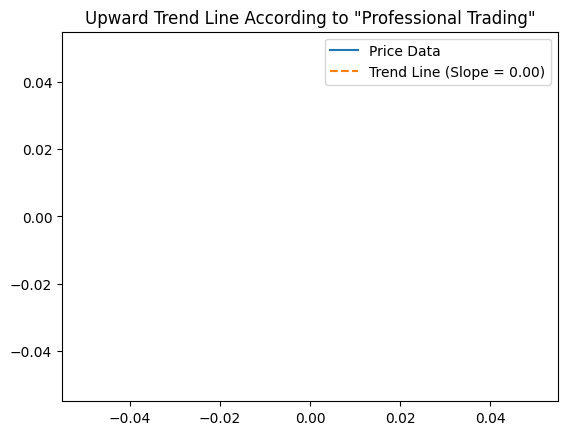

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
from src.io.read_data import load_stocks_data

# 加载数据
df = load_stocks_data("nvda", "2025-04-21")[pd.to_datetime("2024-09-21") : pd.to_datetime("2025-04-21")]
print(df.tail(10))

# 找到非 NaN 的局部极小值
troughs = (
    df[(df["close"] <= df["close"].shift(1)) & (df["close"] <= df["close"].shift(-1))]
    .dropna()
    .sort_values(by="close")
)
print(troughs)

# 确保可以通过索引提取局部极小值
start_idx = df.index.get_loc(troughs.index[0])  # 第一个局部极小值位置
end_idx = df.index.get_loc(troughs.index[-1])  # 最后一个局部极小值位置

# 提取 x 和 y 值
x_values = df.index[
    start_idx : end_idx + 1
].tolist()  # 包含终止点，+1 是因为切片是左闭右开
y_values = df["close"][start_idx : end_idx + 1].tolist()

# 计算斜率并延伸趋势线
slope = (y_values[-1] - y_values[0]) / (len(x_values) - 1) if len(x_values) > 1 else 0
trend_line = [y_values[0] + i * slope for i in range(len(x_values))]

# 绘制趋势线
plt.plot(x_values, y_values, label="Price Data")
plt.plot(x_values, trend_line, "--", label=f"Trend Line (Slope = {slope:.2f})")
plt.legend()
plt.title('Upward Trend Line According to "Professional Trading"')
plt.show()